### Importing packages

In [ ]:
import gym
import asset_price_process
import option_price_process
import HedgeEnv
import machin
import numpy as np
import torch
import matplotlib.pyplot as plt
import tensorflow as tf
from asset_price_process import GBM
from option_price_process import BSM
from HedgeEnv import env_hedging
from machin.frame.algorithms import DQN
from machin.frame.transition import Transition
from torch import nn
import time


### Setting Up Environment, Asset Price model, and Option Pricing Model

In [38]:
seed = 345
np.random.seed(seed)
torch.manual_seed(seed)
tf.random.set_seed(seed)

tim = time.time()

mu = 0
dt = 1/5
T = 10
num_steps = int(T/dt)
s_0 = 100
strike_price = s_0
sigma = 0.5
r = 0

apm = GBM(mu=mu, dt=dt, s_0=s_0, sigma=sigma)
opm = BSM(strike_price=strike_price, risk_free_interest_rate=r, volatility=sigma, T=T, dt=dt)
env = env_hedging(asset_price_model=apm, dt=dt, T=T, num_steps=num_steps, trading_cost_para=1,
                     L=100, strike_price=strike_price, int_holdings=False, initial_holding=0, mode="PL",
                  option_price_model=opm)


### Untrained Agent making random actions

We simulate a BSM world, but modified to re
ect the realities of trading: Discrete time
and space. We consider a stock whose price process is a geometric Brownian motion (GBM)
with initial price S0 and daily lognormal volatility of =day

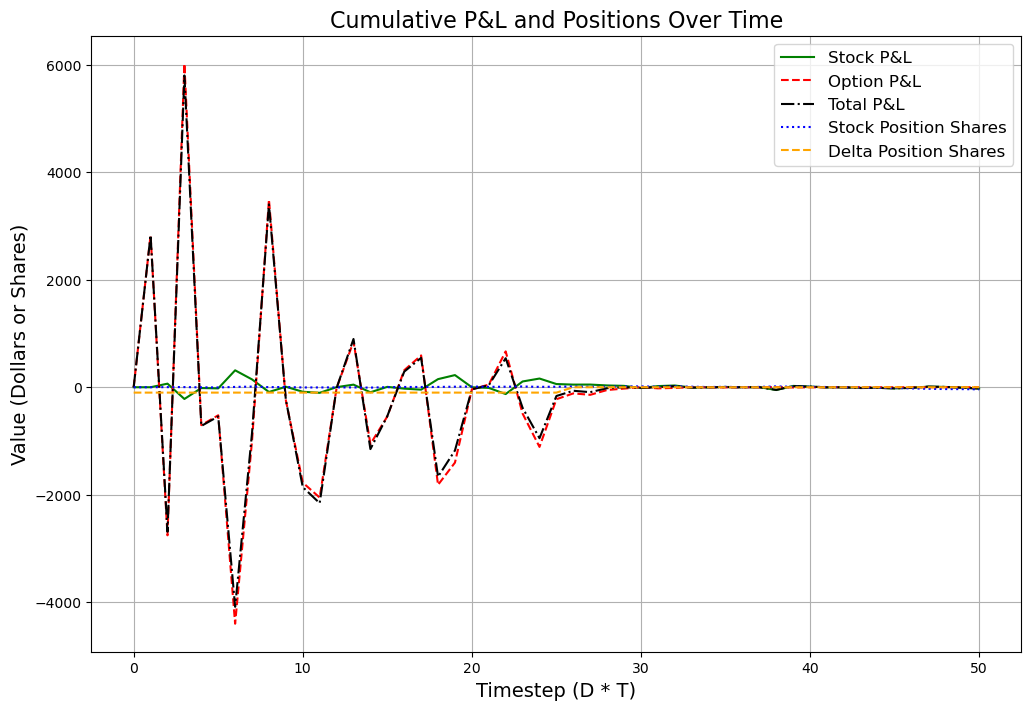

In [39]:
seed = 345
np.random.seed(seed)
torch.manual_seed(seed)
tf.random.set_seed(seed)


def cost(delta_h, multiplier):
    TickSize = 0.1
    return multiplier * TickSize * (np.abs(delta_h) + 0.01 * delta_h**2)

num_episodes = 1

for episode in range(num_episodes): 
    state = env.reset()
    done = False
    cum_option_pnl = 0
    cum_stock_pnl = 0
    option_pnls = [0]
    stock_pnls = [0]
    total_pnl = [0]
    stock_pos_shares =[state[0]]
    delta_pos_shares = [-100*round(state[4])]
    

    while not done:
        current_state = env.get_state()
        delta_action = -100 * round(current_state[4])
        action = env.action_space.sample()
        next_state, reward, done, info = env.step(action-10)
        delta_h =   next_state[0] -current_state[0]
        option_pnl = 100*(next_state[3]-current_state[3])
        stock_pnl = -next_state[0]*(next_state[1] -current_state[1])- cost(delta_h, 0)
        cum_option_pnl =+ option_pnl
        cum_stock_pnl =+ stock_pnl

        option_pnls.append(cum_option_pnl)
        stock_pnls.append(cum_stock_pnl)
        total_pnl.append(cum_option_pnl+cum_stock_pnl)
        stock_pos_shares.append(next_state[0])
        delta_pos_shares.append(delta_action)

time_axis = np.linspace(0, num_steps, num_steps + 1)
plt.figure(figsize=(12, 8))
plt.plot(time_axis, stock_pnls, label='Stock P&L', color='green', linestyle='-')
plt.plot(time_axis, option_pnls, label='Option P&L', color='red', linestyle='--')
plt.plot(time_axis, total_pnl, label='Total P&L', color='black', linestyle='-.')
plt.plot(time_axis, stock_pos_shares, label='Stock Position Shares', color='blue', linestyle=':')
plt.plot(time_axis, delta_pos_shares, label='Delta Position Shares', color='orange', linestyle='--')

# Add labels, title, and legend
plt.xlabel('Timestep (D * T)', fontsize=14)
plt.ylabel('Value (Dollars or Shares)', fontsize=14)
plt.title('Cumulative P&L and Positions Over Time', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)

# Show the plot
plt.show()

### Trained DQN Agent 

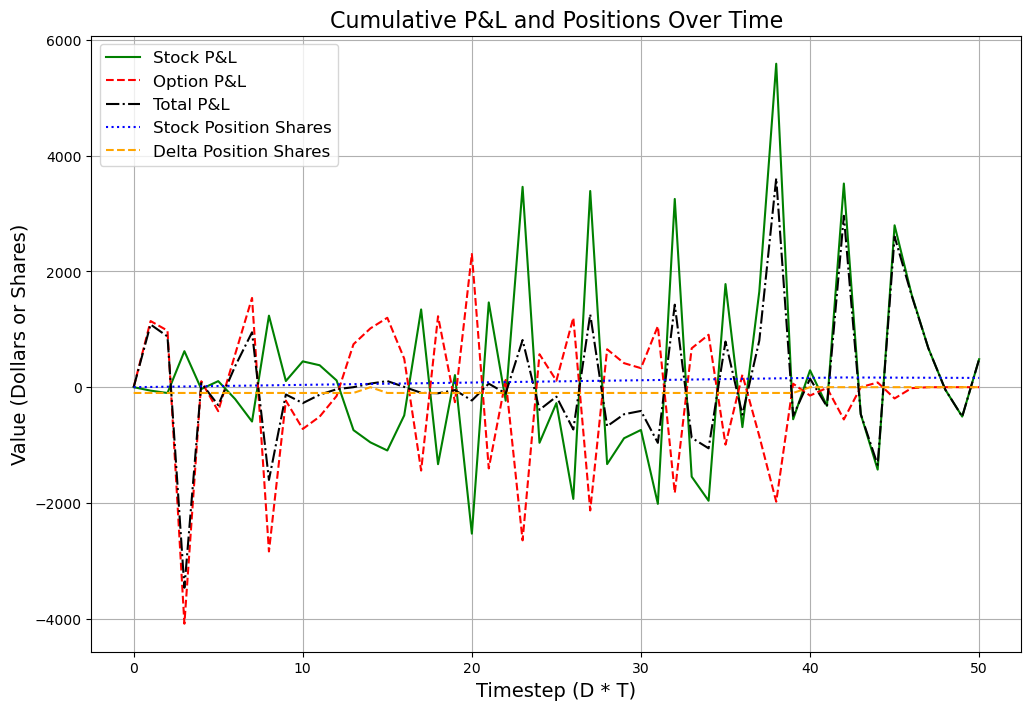

In [40]:
from stable_baselines3 import DQN

seed = 345
np.random.seed(seed)
torch.manual_seed(seed)
tf.random.set_seed(seed)


model = DQN("MlpPolicy", env, verbose= 0)
model.learn(total_timesteps=10000, log_interval = 4)
model.save("dqn_hedge")

del model

model = DQN.load("dqn_hedge")

num_episodes = 10

for episode in range(num_episodes): 
    state = env.reset()
    done = False
    cum_option_pnl = 0
    cum_stock_pnl = 0
    option_pnls = [0]
    stock_pnls = [0]
    total_pnl = [0]
    stock_pos_shares =[state[0]]
    delta_pos_shares = [-100*round(state[4])]
    
    while not done:
        current_state = env.get_state()
        delta_action = -100 * round(current_state[4])
        action, _states = model.predict(current_state, deterministic = True)
        next_state, reward, done, info = env.step(action-10)
        delta_h =   next_state[0] -current_state[0]
        option_pnl = 100*(next_state[3]-current_state[3])
        stock_pnl = -next_state[0]*(next_state[1] -current_state[1])- cost(delta_h, 0)
        cum_option_pnl =+ option_pnl
        cum_stock_pnl =+ stock_pnl

        option_pnls.append(cum_option_pnl)
        stock_pnls.append(cum_stock_pnl)
        total_pnl.append(cum_option_pnl+cum_stock_pnl)
        stock_pos_shares.append(next_state[0])
        delta_pos_shares.append(delta_action)
        if done:
            state = env.reset()

time_axis = np.linspace(0, num_steps, num_steps + 1)
plt.figure(figsize=(12, 8))
plt.plot(time_axis, stock_pnls, label='Stock P&L', color='green', linestyle='-')
plt.plot(time_axis, option_pnls, label='Option P&L', color='red', linestyle='--')
plt.plot(time_axis, total_pnl, label='Total P&L', color='black', linestyle='-.')
plt.plot(time_axis, stock_pos_shares, label='Stock Position Shares', color='blue', linestyle=':')
plt.plot(time_axis, delta_pos_shares, label='Delta Position Shares', color='orange', linestyle='--')

# Add labels, title, and legend
plt.xlabel('Timestep (D * T)', fontsize=14)
plt.ylabel('Value (Dollars or Shares)', fontsize=14)
plt.title('Cumulative P&L and Positions Over Time', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)

plt.show()


# Build the Deep Hedging Agent

In [ ]:
# import math
# import random
# import matplotlib
# import matplotlib.pyplot as plt
# from collections import namedtuple, deque
# from itertools import count

# import torch
# import torch.nn as nn
# import torch.optim as optim
# import torch.nn.functional as F

# is_ipython = 'inline' in matplotlib.get_backend()
# if is_ipython:
#     from IPython import display

# plt.ion()


# device = torch.device(
#     "cuda" if torch.cuda.is_available() else
#     "mps" if torch.backends.mps.is_available() else
#     "cpu"
# )


In [ ]:
# Transition = namedtuple('Transition',
#                         ('state', 'action', 'next_state', 'reward'))


# class ReplayMemory(object):

#     def __init__(self, capacity):
#         self.memory = deque([], maxlen=capacity)

#     def push(self, *args):
#         """Save a transition"""
#         self.memory.append(Transition(*args))

#     def sample(self, batch_size):
#         return random.sample(self.memory, batch_size)

#     def __len__(self):
#         return len(self.memory)

In [ ]:
# class DQN(nn.Module):

#     def __init__(self, n_observations, n_actions):
#         super(DQN, self).__init__()
#         self.layer1 = nn.Linear(n_observations, 128)
#         self.layer2 = nn.Linear(128, 128)
#         self.layer3 = nn.Linear(128, n_actions)

#     # Called with either one element to determine next action, or a batch
#     # during optimization. Returns tensor([[left0exp,right0exp]...]).
#     def forward(self, x):
#         x = F.relu(self.layer1(x))
#         x = F.relu(self.layer2(x))
#         return self.layer3(x)


In [ ]:
# def optimize_model():
#     if len(memory) < BATCH_SIZE:
#         return
#     transitions = memory.sample(BATCH_SIZE)
#     # Transpose the batch (see https://stackoverflow.com/a/19343/3343043 for
#     # detailed explanation). This converts batch-array of Transitions
#     # to Transition of batch-arrays.
#     batch = Transition(*zip(*transitions))

#     # Compute a mask of non-final states and concatenate the batch elements
#     # (a final state would've been the one after which simulation ended)
#     non_final_mask = torch.tensor(tuple(map(lambda s: s is not None,
#                                           batch.next_state)), device=device, dtype=torch.bool)
#     non_final_next_states = torch.cat([s for s in batch.next_state
#                                                 if s is not None])
#     state_batch = torch.cat(batch.state)
#     action_batch = torch.cat(batch.action)
#     reward_batch = torch.cat(batch.reward)

#     # Compute Q(s_t, a) - the model computes Q(s_t), then we select the
#     # columns of actions taken. These are the actions which would've been taken
#     # for each batch state according to policy_net
#     state_action_values = policy_net(state_batch).gather(1, action_batch)

#     # Compute V(s_{t+1}) for all next states.
#     # Expected values of actions for non_final_next_states are computed based
#     # on the "older" target_net; selecting their best reward with max(1).values
#     # This is merged based on the mask, such that we'll have either the expected
#     # state value or 0 in case the state was final.
#     next_state_values = torch.zeros(BATCH_SIZE, device=device)
#     with torch.no_grad():
#         next_state_values[non_final_mask] = target_net(non_final_next_states).max(1).values
#     # Compute the expected Q values
#     expected_state_action_values = (next_state_values * GAMMA) + reward_batch

#     # Compute Huber loss
#     criterion = nn.SmoothL1Loss()
#     loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

#     # Optimize the model
#     optimizer.zero_grad()
#     loss.backward()
#     # In-place gradient clipping
#     torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
#     optimizer.step()

In [ ]:
# if torch.cuda.is_available() or torch.backends.mps.is_available():
#     num_episodes = 600
# else:
#     num_episodes = 50

# for i_episode in range(num_episodes):
#     # Initialize the environment and get its state
#     state, info = env.reset()
#     state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
#     for t in count():
#         action = select_action(state)
#         observation, reward, terminated = env.step(action.item())
#         reward = torch.tensor([reward], device=device)
#         done = terminated 

#         if terminated:
#             next_state = None
#         else:
#             next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)

#         # Store the transition in memory
#         memory.push(state, action, next_state, reward)

#         # Move to the next state
#         state = next_state

#         # Perform one step of the optimization (on the policy network)
#         optimize_model()

#         # Soft update of the target network's weights
#         # θ′ ← τ θ + (1 −τ )θ′
#         target_net_state_dict = target_net.state_dict()
#         policy_net_state_dict = policy_net.state_dict()
#         for key in policy_net_state_dict:
#             target_net_state_dict[key] = policy_net_state_dict[key]*TAU + target_net_state_dict[key]*(1-TAU)
#         target_net.load_state_dict(target_net_state_dict)

#         if done:
#             episode_durations.append(t + 1)
#             plot_durations()
#             break

# print('Complete')
# plot_durations(show_result=True)
# plt.ioff()
# plt.show()

In [ ]:
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Flatten
# from tensorflow.keras.optimizers import Adam
# from rl.agents import DQNAgent
# from rl.policy import BoltzmannQPolicy
# from rl.memory import SequentialMemory

In [ ]:
# def build_agent(model, actions):
#     policy = BoltzmannQPolicy()
#     memory = SequentialMemory(limit=50000, window_length=1)
#     dqn = DQNAgent(model=model, memory=memory, policy=policy, 
#                   nb_actions=actions, nb_steps_warmup=10, target_model_update=1e-2)
#     return dqn



In [ ]:
# dqn = build_agent(model, actions)
# dqn.compile(Adam(lr=1e-3), metrics=['mae'])
# dqn.fit(env, nb_steps=50000, visualize=False, verbose=1)

In [ ]:
# class QNet(nn.Module):
#     def __init__(self, state_dim, hidden_dim, action_num):
#         super(QNet, self).__init__()

#         self.fc1 = nn.Linear(state_dim, hidden_dim)
#         self.fc2 = nn.Linear(hidden_dim, hidden_dim)
#         self.fc3 = nn.Linear(hidden_dim, action_num)

#     def forward(self, state):
#         a = torch.relu(self.fc1(state))
#         a = torch.relu(self.fc2(a))
#         return self.fc3(a)

# qnet = QNet(4, 20, num_actions)
# qnet_t = QNet(4, 20, num_actions)

# dqn = DQN(qnet, qnet_t,
#           torch.optim.Adam,
#           nn.MSELoss(reduction='sum'), discount=0.8, epsilon_decay=0.999, learning_rate=0.001,
#           lr_scheduler=torch.optim.lr_scheduler.StepLR, lr_scheduler_kwargs=[{"step_size": 1000*128}])

# num_eps = 5000
# norm_factor = 10000000


# def test_delta(n=10):
#     rew = []
#     for i in range(n):
#         state = env.reset()
#         done = False
#         state = state[[0, 1, 2, 4]]
#         while not done:
#             action = state[3] - env.h
#             new_state, reward, done = env.step(action)
#             reward = np.sum(reward)
#             new_state = new_state[[0, 1, 2, 4]]
#             reward = -(reward) ** 2 + 1 / 1000 * reward
#             #reward = -(action + env.h - state[3]) ** 2  # remove that
#             rew.append(reward)
#             state = new_state
#     return np.mean(rew)


# def test(n=10):
#     rew = []
#     for i in range(n):
#         state = env.reset()
#         done = False
#         state = state[[0, 1, 2, 4]]
#         while not done:
#             out = dqn.act_discrete({"state": torch.tensor(state, dtype=torch.float32).unsqueeze(0)})
#             action = out.squeeze().detach().numpy() / num_actions
#             new_state, reward, done = env.step(action - env.h)
#             reward = np.sum(reward)
#             new_state = new_state[[0, 1, 2, 4]]
#             reward = -(reward) ** 2 + 1 / 1000 * reward
#             #reward = -(action + env.h - state[3]) ** 2  # remove that
#             if i == 1:
#                 print(action, state[3])
#             rew.append(reward)
#             state = new_state
#     return np.mean(rew)

# rew = []

# for j in range(num_eps):
#     print("episode: ", j)
#     state = env.reset()
#     done = False
#     state = state[[0,1,2,4]]
#     while not done:
#         out = dqn.act_discrete_with_noise({"state": torch.tensor(state, dtype=torch.float32).unsqueeze(0)})
#         action = out.squeeze().detach().numpy()/num_actions - env.h
#         new_state, reward, done = env.step(action)
#         #print(action)
#         #print(reward)
#         reward = np.sum(reward)
#         #print(reward)
#         new_state = new_state[[0, 1, 2, 4]]
#         #print(state)
#         reward = -norm_factor*((reward) ** 2 + 1 / 1000 * reward)
#         rew.append(reward)

#         dqn.store_transition({
#             "state": {"state": torch.tensor(state, dtype=torch.float32).unsqueeze(0)},
#             "action": {"action": out},
#             "next_state": {"state": torch.tensor(new_state, dtype=torch.float32).unsqueeze(0)},
#             "reward": float(reward),  # norm factor
#             "terminal": done
#         })
#         state = new_state

#     if j % 50 == 0 and j != 0:
#         print(test(10), test_delta(10))
#         print("reward: ", np.mean(rew), np.mean(rew)/norm_factor)
#         rew = []

#     if j > 100:
#         for _ in range(int(num_steps)):
#             dqn.update()

# #dqn.save("dqn_model_1000")

# rew_m_l = []
# cost_m_l = []
# for j in range(100):
#     rew = []
#     cost_l = []
#     state = env.reset()
#     done = False
#     state = state[[0,1,2,4]]
#     while not done:
#         out = dqn.act_discrete({"state": torch.tensor(state, dtype=torch.float32).unsqueeze(0)})
#         action = out.squeeze().detach().numpy()/num_actions - env.h
#         new_state, reward, done = env.step(action)
#         cost = reward[1]
#         reward = np.sum(reward)

#         new_state = new_state[[0, 1, 2, 4]]
#         rew.append(reward)
#         cost_l.append(cost)
#         state = new_state
#     rew_m_l.append(np.sum(rew))
#     cost_m_l.append(np.sum(cost_l))
# print("__________")
# print(rew_m_l)
# print(np.mean(rew_m_l), np.std(rew_m_l))
# print("__________")
# print(cost_m_l)
# print(np.mean(cost_m_l), np.std(cost_m_l))

# rew_m_l = []
# cost_m_l = []
# for j in range(100):
#     rew = []
#     cost_l = []
#     state = env.reset()
#     done = False
#     state = state[[0, 1, 2, 4]]
#     while not done:
#         action = state[3] - env.h
#         new_state, reward, done = env.step(action)
#         cost = reward[1]
#         reward = np.sum(reward)

#         new_state = new_state[[0, 1, 2, 4]]
#         rew.append(reward)
#         cost_l.append(cost)
#         state = new_state
#     rew_m_l.append(np.sum(rew))
#     cost_m_l.append(np.sum(cost_l))
# print("__________")
# print(rew_m_l)
# print(np.mean(rew_m_l), np.std(rew_m_l))
# print("__________")
# print(cost_m_l)
# print(np.mean(cost_m_l), np.std(cost_m_l))
# print("__________")
# print(tim - time.time())